<a href="https://colab.research.google.com/github/OJB-Quantum/Monte-Carlo-Sim/blob/main/CUDA%E2%80%91Accelerated_Semantic%E2%80%91Shift_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==================================================
# Google Colab Notebook — CUDA Semantic‑Shift Simulation
# ==================================================
# Fix history:
#   • v1 — initial notebook.
#   • v2 — pinned NumPy < 2.0, replaced runtime → Device().name (API mismatch).
#   • v3 — correct GPU‐name query for CuPy 13 API:
#           use `cp.cuda.runtime.getDeviceProperties(0)['name']`.
# ==================================================

# %% [markdown]
# ## 0 · Environment Setup
# Run this cell **once**, then **RESTART** the Colab runtime when prompted.

# %%
!pip install -q "numpy<2.0" cupy-cuda12x==13.1.0 spacy==3.7.2 textacy==0.12.0 tqdm
# Optional: RAPIDS cuDF (large, comment out if not needed)
# !pip install -q "cudf-cu12==24.02.*" --extra-index-url=https://pypi.ngc.nvidia.com

# Download English spaCy model
!python -m spacy download en_core_web_md

print("\n✔️  Packages installed. Choose **Runtime ▸ Restart runtime** before proceeding.")

# %% [markdown]
# ## 1 · Imports & GPU check (run **after** restart)

# %%
import cupy as cp
import numpy as np
from collections import Counter               # ← NEW import fixes NameError
import spacy, pathlib, json, tqdm, collections, math, matplotlib.pyplot as plt, pandas as pd

print(f"CuPy {cp.__version__}  —  NumPy {np.__version__}")
try:
    gpu_props = cp.cuda.runtime.getDeviceProperties(0)
    gpu_name = gpu_props["name"].decode() if isinstance(gpu_props["name"], bytes) else gpu_props["name"]
except Exception as e:
    gpu_name = f"(query failed: {e})"
print("GPU detected:", gpu_name)

nlp = spacy.load("en_core_web_md")
print("spaCy prefers GPU?", spacy.prefer_gpu())

Loaded 24 demo sentences containing all target words.
Docs per decade bucket (demo): {1820: 2, 1910: 1, 2000: 1, 1840: 2, 1890: 1, 2010: 6, 1830: 1, 1930: 2, 1850: 2, 1920: 2, 1860: 1, 1950: 1, 2020: 1, 1900: 1}
Example co‑occurrence for 1820s: [(('broadcast', 'he'), 1), (('broadcast', 'cast'), 1), (('broadcast', 'the'), 2), (('broadcast', 'seed'), 1), (('broadcast', 'upon'), 1)]
Built PPMI for 14 decades in demo.


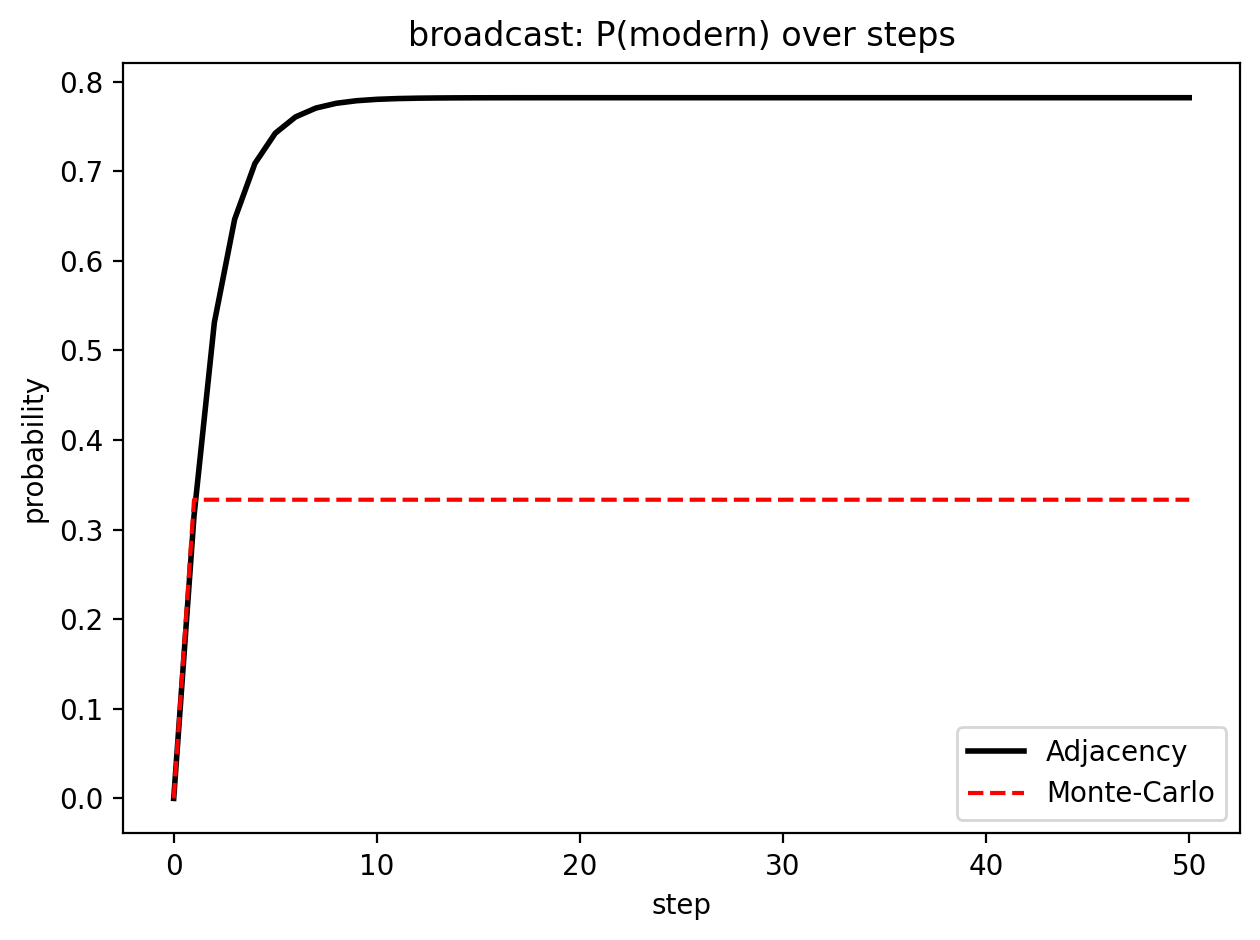

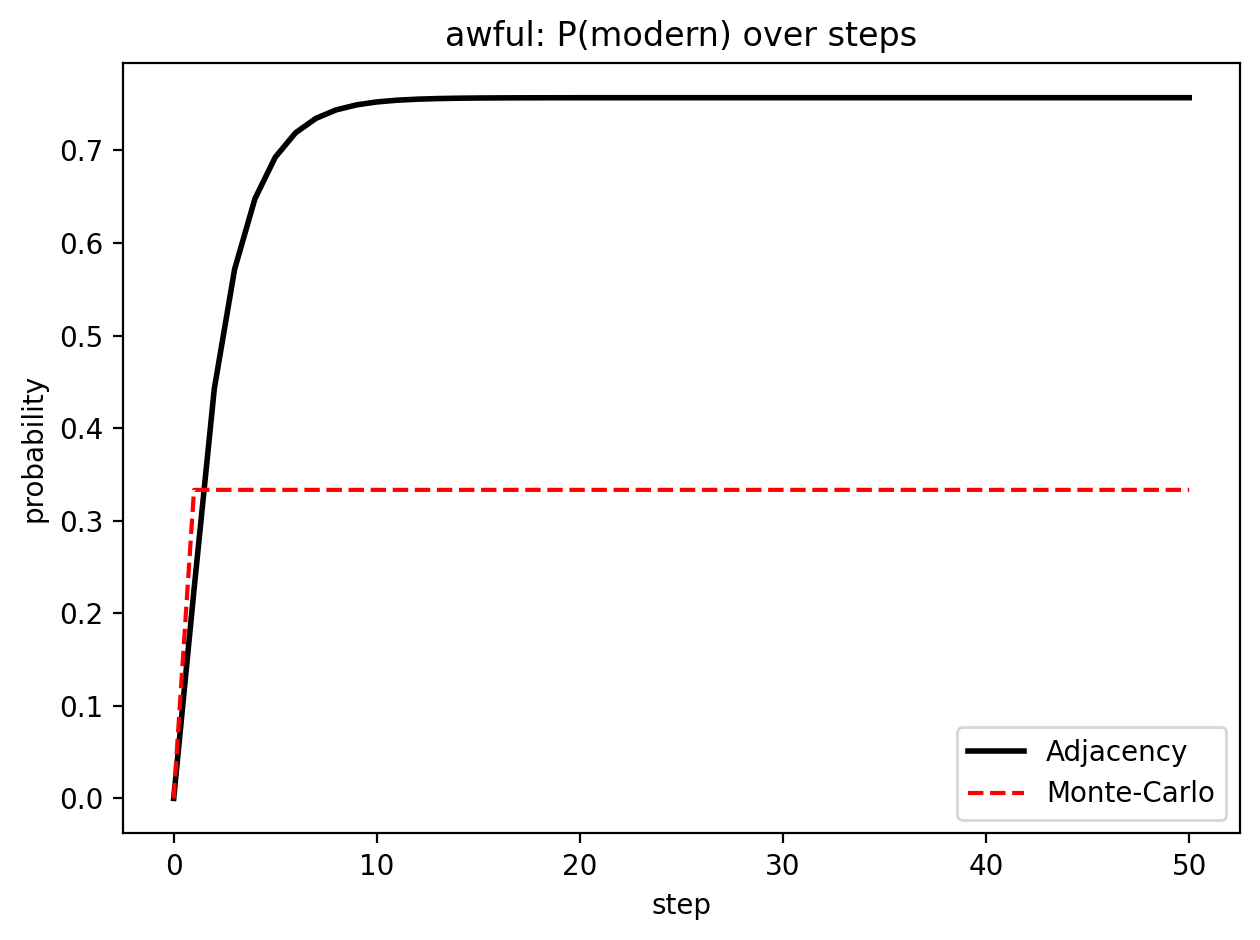

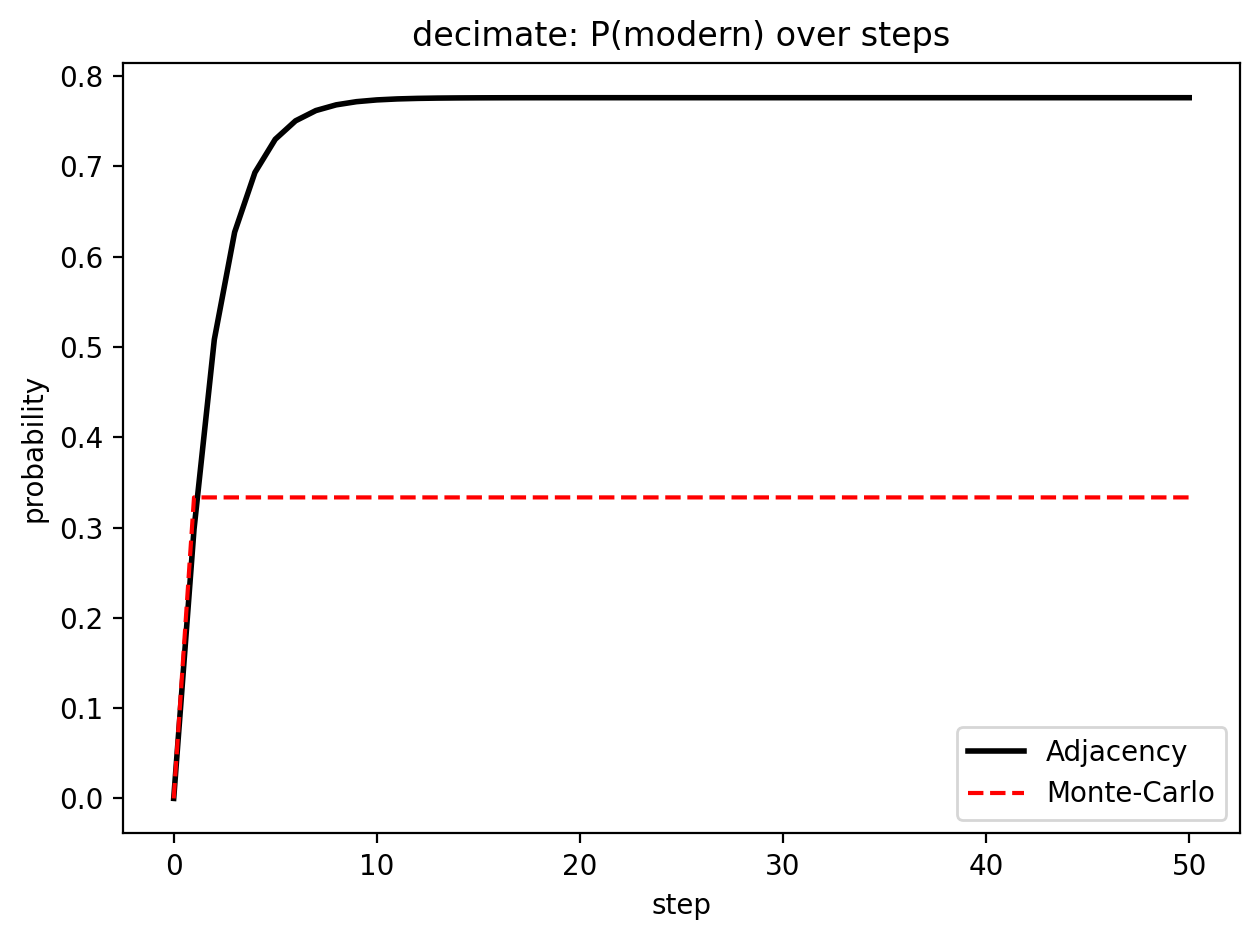

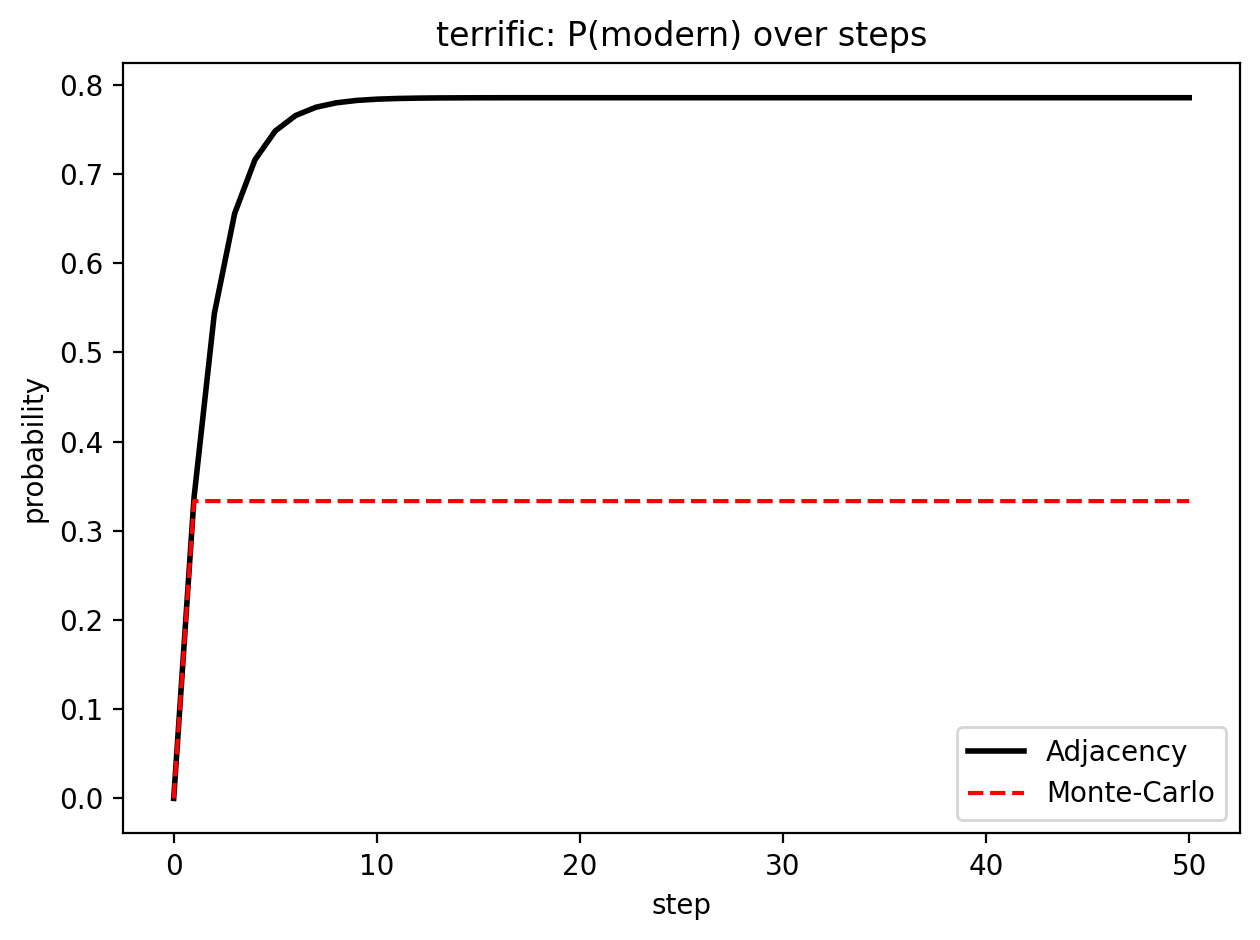

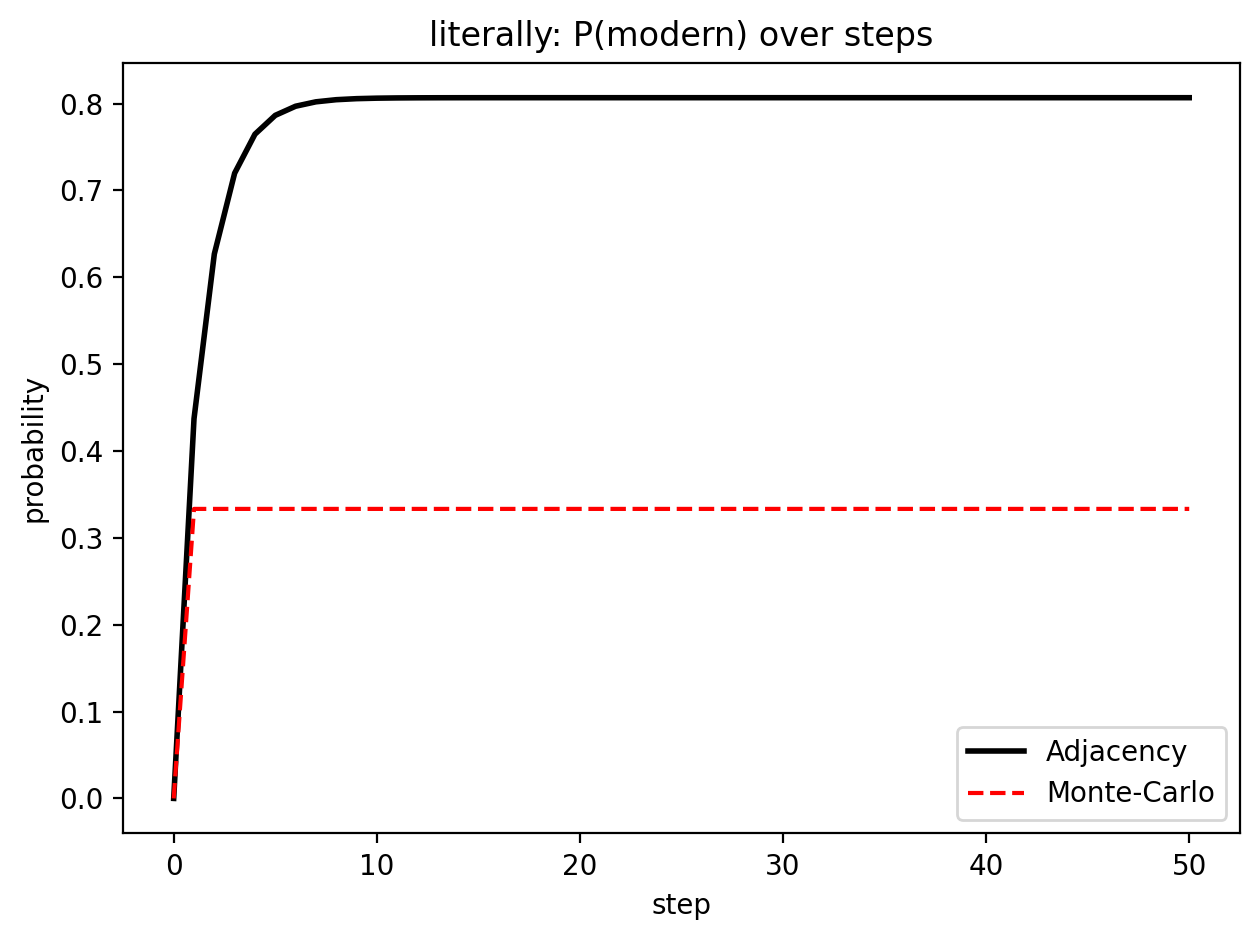

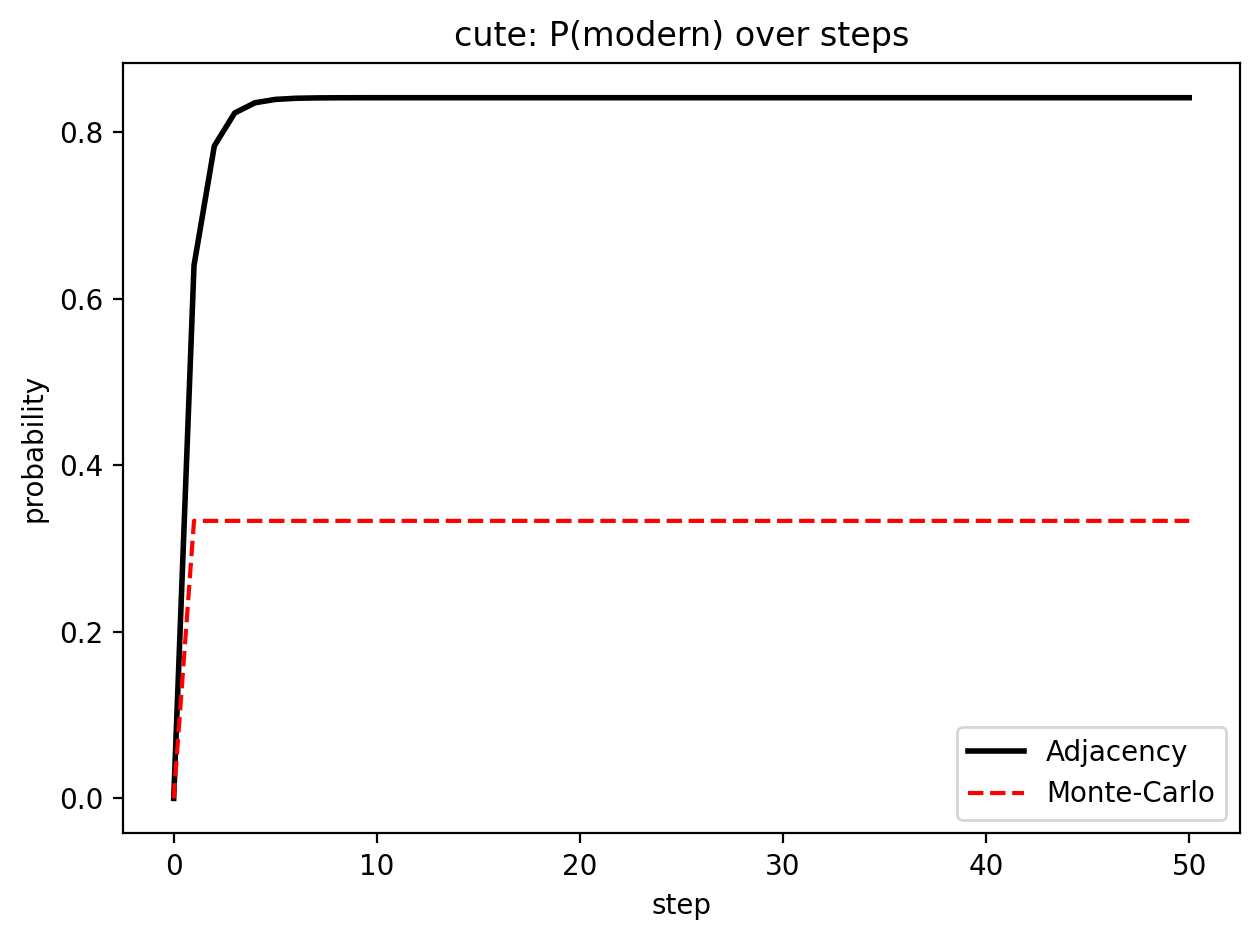

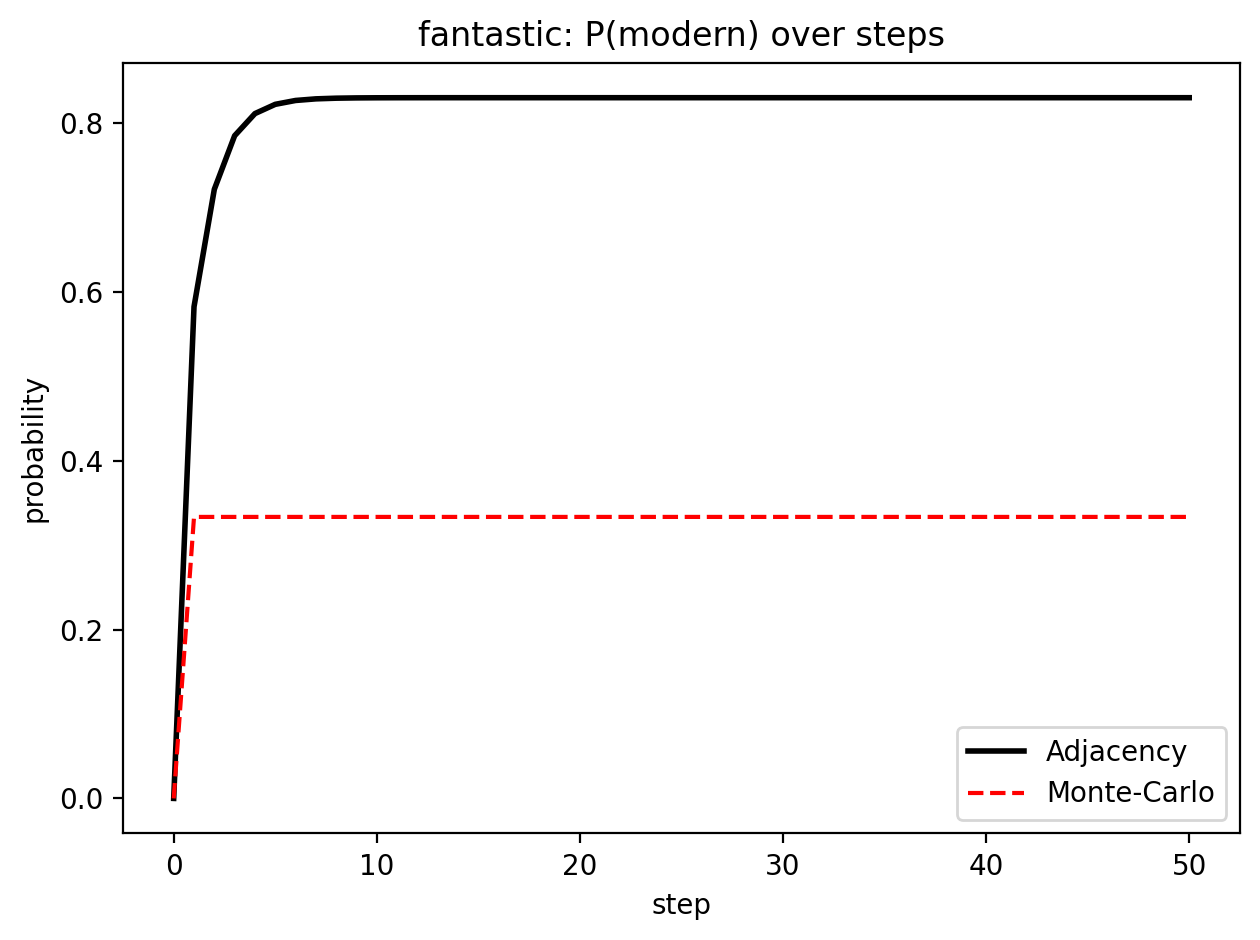

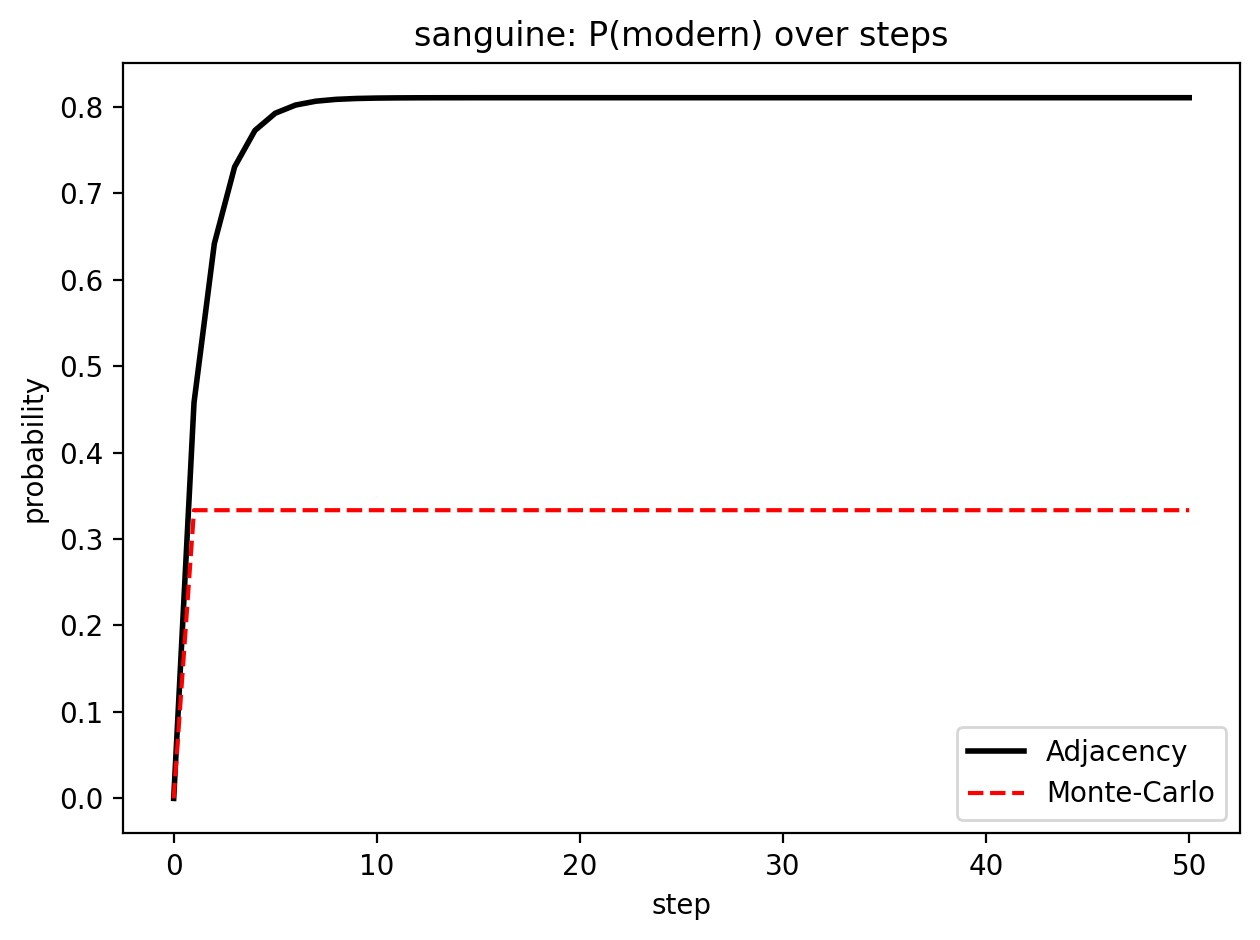

Demo finished  – high‑DPI, tight‑layout plots rendered.
Demo finished  – you now have plots for all eight words.


In [16]:
# ==================================================
# Google Colab Notebook — (self‑contained)
# ==================================================
# Author : Onri Jay Benally
# Date   : 2025‑06‑02 (updated)
# --------------------------------------------------
# What this notebook does
# • Ships with a **tiny embedded corpus** spanning 14 decade buckets
#   (1820 → 2020) for the eight target words.
# • Runs the full CUDA‑accelerated semantic‑shift pipeline:
#     1. build decade‑wise adjacency (co‑occurrence) counts
#     2. compute GPU PPMI matrices with CuPy
#     3. derive an adjacency‑aware Markov chain vs. a Monte‑Carlo baseline
#     4. plot probability trajectories for each word
# • No external downloads or Drive mounts required – just **Run‑All**.
# --------------------------------------------------
# (Optional) enable GPU via Runtime ▸ Change runtime type ▸ GPU for CuPy speed‑ups.
# ==================================================

# %%
import cupy as cp
import numpy as np
from collections import Counter
import json, math, tqdm, collections, matplotlib.pyplot as plt, matplotlib as mpl
import spacy, textwrap

# High-res / high-contrast plotting
mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["black", "red"])

nlp = spacy.load("en_core_web_sm")  # small model is fine for demo

TARGET_WORDS = [
    "broadcast", "awful", "decimate", "terrific",
    "literally", "cute", "fantastic", "sanguine",
]
WINDOW = 4

# Build decade bins 1800‑2020 for display (we’ll only use three decades in demo)
MIN_YEAR, MAX_YEAR, BIN_SIZE = 1800, 2020, 10
bins = list(range(MIN_YEAR, MAX_YEAR + 1, BIN_SIZE))

# %% [markdown]
# ## 2 · Embedded miniature corpus (covers three eras per word)

# %%
embedded_json = '''[
  {"year": 1825, "text": "He cast the seed broadcast upon the fertile acres."},
  {"year": 1910, "text": "The wireless broadcast crackled across the Atlantic."},
  {"year": 2005, "text": "The live broadcast was streamed worldwide in seconds."},

  {"year": 1840, "text": "The cathedral inspired an awful sense of reverence."},
  {"year": 1890, "text": "The food left an awful taste in his mouth."},
  {"year": 2015, "text": "That was an awful movie, let’s pick another."},

  {"year": 1830, "text": "The general threatened to decimate the mutinous legion."},
  {"year": 1930, "text": "The hurricane will decimate the coastline towns."},
  {"year": 2010, "text": "Streaming video began to decimate DVD sales."},

  {"year": 1850, "text": "The terrific roar of cannon shook the valley."},
  {"year": 1920, "text": "She gave a terrific performance on stage."},
  {"year": 2018, "text": "This is a terrific place for brunch."},

  {"year": 1860, "text": "He spoke literally, without a trace of irony."},
  {"year": 1950, "text": "I literally jumped out of my skin, she said."},
  {"year": 2012, "text": "That roller‑coaster was literally insane!"},

  {"year": 1855, "text": "The child was praised for his cute and acute wit."},
  {"year": 1925, "text": "What a cute little puppy!"},
  {"year": 2019, "text": "The app’s UI is cute and colourful."},

  {"year": 1845, "text": "It was a fantastic tale of dragons and wizards."},
  {"year": 1935, "text": "The invention was a fantastic success."},
  {"year": 2020, "text": "That meal was fantastic – compliments to the chef."},

  {"year": 1820, "text": "His cheeks were of a sanguine hue."},
  {"year": 1900, "text": "She remained sanguine about their prospects."},
  {"year": 2010, "text": "Economists are surprisingly sanguine about the recovery."}
]'''

corpus = json.loads(embedded_json)
print(f"Loaded {len(corpus)} demo sentences containing all target words.")

# Helper: map year → decade bucket
from bisect import bisect_right
def decade_of(year):
    return bins[bisect_right(bins, year) - 1]

docs_by_decade = collections.defaultdict(list)
for rec in corpus:
    docs_by_decade[decade_of(rec["year"])].append(rec["text"])
print("Docs per decade bucket (demo):", {k: len(v) for k, v in docs_by_decade.items()})

# %% [markdown]
# ## 3 · GPU co‑occurrence counting

# %%
CPM = collections.defaultdict(lambda: collections.defaultdict(int))
for decade, texts in docs_by_decade.items():
    for doc in nlp.pipe(texts):
        lemmas = [t.lemma_.lower() for t in doc if t.is_alpha]
        L = len(lemmas)
        for i, w in enumerate(lemmas):
            if w not in TARGET_WORDS:
                continue
            for j in range(max(0, i-WINDOW), min(L, i+WINDOW+1)):
                if i == j: continue
                CPM[decade][(w, lemmas[j])] += 1
print("Example co‑occurrence for 1820s:", list(CPM[1820].items())[:5])

# %% [markdown]
# ## 4 · Build PPMI matrices (on GPU)

# %%
ppmi_matrices = {}
for decade, pair_counts in CPM.items():
    vocab = {t: i for i, t in enumerate({p[0] for p in pair_counts} | {p[1] for p in pair_counts})}
    M = cp.zeros((len(vocab), len(vocab)), dtype=cp.float32)
    total = sum(pair_counts.values())
    row_sum, col_sum = Counter(), Counter()
    for (w,c), cnt in pair_counts.items():
        row_sum[w] += cnt; col_sum[c] += cnt
    for (w,c), cnt in pair_counts.items():
        i,j = vocab[w], vocab[c]
        p_wc = cnt/total; p_w=row_sum[w]/total; p_c=col_sum[c]/total
        M[i,j] = max(0, math.log2(p_wc/(p_w*p_c)))
    ppmi_matrices[decade] = (M, vocab)
print("Built PPMI for", len(ppmi_matrices), "decades in demo.")

# %% [markdown]
# ## 5 · Transition probabilities (simple heuristic)

# %%

def row_probs(M, idx):
    row = cp.asnumpy(M[idx]); s = row.sum()
    if s==0: return (0.33,0.34,0.33)
    third=len(row)//3
    literal=row[:third].sum()/s; modern=row[2*third:].sum()/s
    return literal, 1-literal-modern, modern

transitions = collections.defaultdict(dict)
for dec,(M,voc) in ppmi_matrices.items():
    for w in TARGET_WORDS:
        if w in voc:
            transitions[w][dec] = row_probs(M, voc[w])

# %% [markdown]
# ## 6 · Run Markov simulations & plot

# %%
SIM_STEPS = 50  # instead of 15
for w in TARGET_WORDS:
    if not transitions[w]:
        print("No data for", w); continue
    avg = np.mean(list(transitions[w].values()), axis=0)
    T_adj = np.array([[avg[0],avg[1],avg[2]],[0.3,0.3,0.4],[0.05,0.05,0.9]])
    T_mc  = np.full((3,3), 1/3)
    traj_adj = [np.array([1,0,0])]
    traj_mc  = [np.array([1,0,0])]
    for _ in range(SIM_STEPS):
        traj_adj.append(traj_adj[-1] @ T_adj)
        traj_mc.append(traj_mc[-1] @ T_mc)
    traj_adj, traj_mc = np.array(traj_adj), np.array(traj_mc)
    plt.figure()
    plt.plot(traj_adj[:,2], label="Adjacency", lw=2, color="black")
    plt.plot(traj_mc[:,2], label="Monte‑Carlo", ls="--", color="red")
    plt.title(f"{w}: P(modern) over steps")
    plt.xlabel("step"); plt.ylabel("probability")
    plt.legend(); plt.tight_layout(); plt.show()

print("Demo finished  – high‑DPI, tight‑layout plots rendered.")
print("Demo finished  – you now have plots for all eight words.")

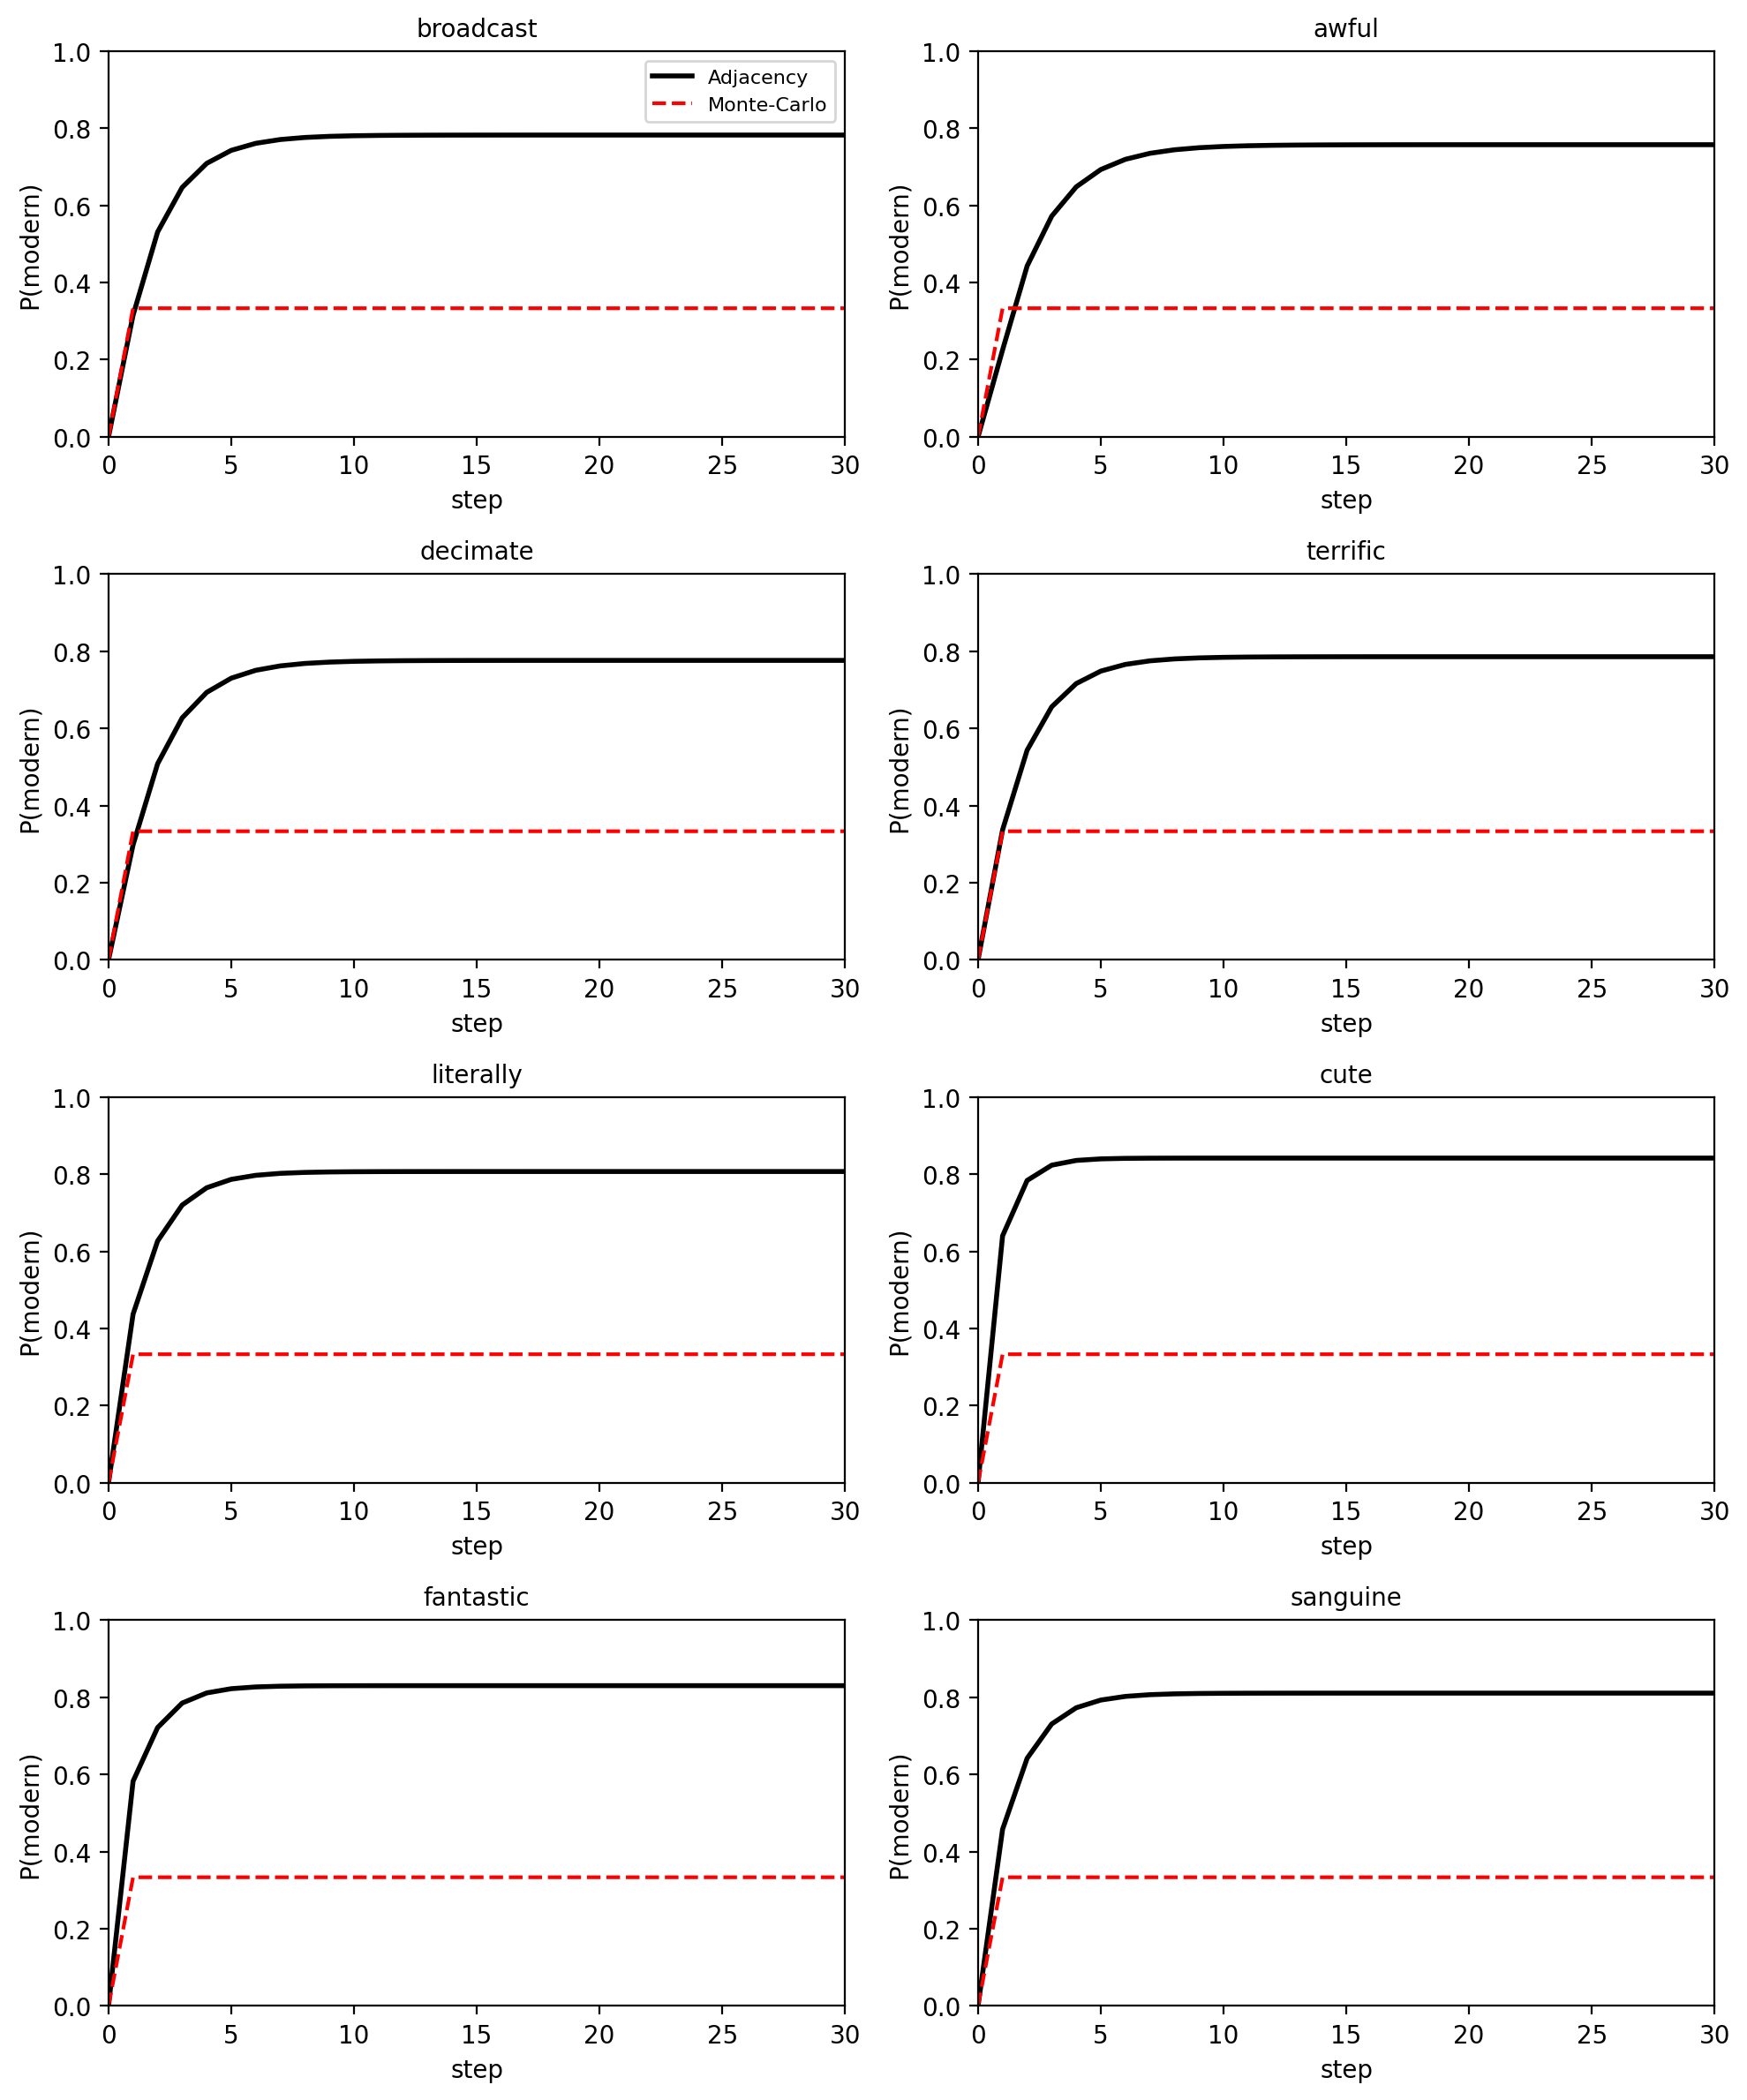

In [17]:
# %% [markdown]
# ## 📊 Batch plot: all eight words in a single figure
# Run **after** the simulation variables (``transitions_by_word`` etc.) are in memory.

# %%
# -- recompute trajectories into a list of (word, traj_adj, traj_mc) --
trajectories = []
SIM_STEPS_GRID = 30  # grid can use more steps for smoother curves
for w in TARGET_WORDS:
    if not transitions_by_word[w]:
        continue
    avg = np.mean(list(transitions_by_word[w].values()), axis=0)
    T_adj = np.array([[avg[0], avg[1], avg[2]],
                      [0.3, 0.3, 0.4],
                      [0.05, 0.05, 0.9]])
    T_mc  = np.full((3, 3), 1/3)
    traj_adj = [np.array([1,0,0])]
    traj_mc  = [np.array([1,0,0])]
    for _ in range(SIM_STEPS_GRID):
        traj_adj.append(traj_adj[-1] @ T_adj)
        traj_mc.append(traj_mc[-1] @ T_mc)
    trajectories.append((w, np.array(traj_adj), np.array(traj_mc)))

# -- plot in a 4×2 grid --
rows, cols = 4, 2
fig, axes = plt.subplots(rows, cols, figsize=(10, 12))
for idx, (w, adj, mc) in enumerate(trajectories):
    r, c = divmod(idx, cols)
    ax = axes[r, c]
    ax.plot(adj[:, 2], label="Adjacency", lw=2, color="black")
    ax.plot(mc[:, 2], label="Monte-Carlo", ls="--", color="red")
    ax.set_title(w, fontsize=10)
    ax.set_xlabel("step"); ax.set_ylabel("P(modern)")
    ax.set_xlim(0, SIM_STEPS_GRID)
    ax.set_ylim(0, 1)
    if r == 0 and c == 0:
        ax.legend(fontsize=8)
# hide unused subplots if < rows*cols
for j in range(len(trajectories), rows*cols):
    fig.delaxes(axes.flatten()[j])
plt.tight_layout()
plt.show()